# Use Greater Tables to create test data

quick_fab data types
--------------------
         Data   types
        -----   -------------------------------------
            d   date
            f   float
            h   hash
            i   integer
            l   log float (greater range than float)
            m   year - month
            p   path (filename)
            r   ratio (smaller floats, for percents)
            sx  string length x
            t   time
            v   very large range float
            w   variable length string
            x   tex text - an equation
            y   year

In [1]:
%load_ext autotime
import greater_tables as gt
from greater_tables import GT, quick_df
import scipy.stats as ss
print( gt.__version__ )

7.2.0
time: 2.35 s (started: 2026-06-12 00:25:23 +01:00)


In [2]:
n = 1000
df1 = quick_df(n, 'iw5', index_levels=1)
df1

metric,shock,utility
i_0,,
generosity,88182,plants reshaping wrenching dissipation interpr...
unclean,112775,lessen
soundly,53060,activating
compost,89224,apportioned sung
canceled,150471,artwork cardboard differentiating appreciably ...
...,...,...
button,122638,regardless
inherits,79523,sundry property comptroller conquering
patience,78297,hora address invigorating hemispheric


time: 94.8 ms (started: 2026-06-12 00:25:25 +01:00)


In [3]:
df1.iloc[:, 1].str.split(' ').map(len).mean(), df1.iloc[:, 1].str.split(' ').map(len).std()

(np.float64(5.134), np.float64(3.736576776409928))

time: 7.99 ms (started: 2026-06-12 00:25:25 +01:00)


<Axes: >

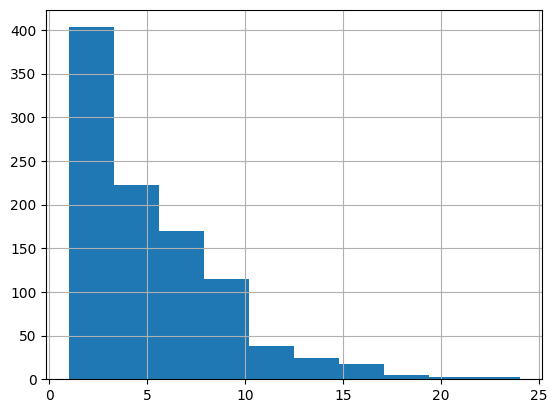

time: 810 ms (started: 2026-06-12 00:25:25 +01:00)


In [4]:
df1.iloc[:, 1].str.split(' ').map(len).hist()

In [14]:
for n in [10, 100, 10_000, 250_000]:
    df1 = quick_df(n, 'dyfivs10', index_levels=1)
    # df1.columns = ['']
    df1.to_csv(f'csv/test-{n}.csv')

In [18]:
n = 250 
df1 = quick_df(n, 'dyfivs10vrffs20', index_levels=1)
# df1.columns = ['']
df1.to_csv(f'csv/test-wide-{n}.csv')

time: 99.4 ms (started: 2026-06-11 13:08:40 +01:00)


In [18]:
n = 1000
df1 = quick_df(n, 'iyffffiiiids2w5w10w20ii', index_levels=1)
# df1.columns = ['']
df1.to_csv(f'csv/variable-text-2-{n}.csv')

time: 179 ms (started: 2026-06-12 23:17:58 +01:00)


In [6]:
n = 250 
df1 = quick_df(n, 'iys2w5idfiw10iw20', index_levels=1)
# df1.columns = ['']
df1.to_csv(f'csv/many-col-variable-text-{n}.csv')

time: 199 ms (started: 2026-06-12 22:14:16 +01:00)


In [9]:
from aggregate import build
a = build('agg A 10 claims sev lognorm 20 cv .8 poisson')
a

,E[X],Est E[X],Err E[X],CV(X),Est CV(X),Err CV(X),Skew(X),Est Skew(X)
X,,,,,,,,
Freq,10.0,NaN,NaN,0.316228,NaN,NaN,0.316228,NaN
Sev,20.0,20.0,-2.318288e-10,0.800000,0.800000,1.385788e-07,2.912000,2.911993
Agg,200.0,200.0,-2.528909e-10,0.404969,0.404969,5.286288e-08,0.664149,0.664149


time: 74.9 ms (started: 2026-06-12 22:15:45 +01:00)


In [10]:
a.density_df.query('p_total > 1e-12').shape

(45052, 17)

time: 104 ms (started: 2026-06-12 22:15:48 +01:00)


In [15]:
a.density_df.query('p_total > 1e-12').to_csv('csv/density_df.csv')

time: 1.69 s (started: 2026-06-12 22:17:44 +01:00)


In [12]:
port  = build('port TEST '
             'agg A dfreq[2:3] dsev[3:19:5] '
             'agg B dfreq[3:5] dsev[2:8:2]')
port

TEST at <aggregate.portfolio.Portfolio object at 0x000001976558E120>

time: 467 ms (started: 2026-06-12 22:17:13 +01:00)


In [16]:
port.density_df.query('p_total > 1e-12').to_csv('csv/port_density_df.csv')

time: 27.8 ms (started: 2026-06-12 22:17:55 +01:00)


In [17]:
port.density_df.query('p_total > 1e-12')

,loss,p_A,p_B,p_total,F,S,exa_total,lev_total,exlea_total,e_total,...,e_B,exgta_B,exi_x_B,exi_xlea_B,exi_xgta_B,exi_xeqa_B,exa_B,exi_xlea_sum,exi_xgta_sum,exi_xeqa_sum
12.0,12.0,0.000000,0.066732,0.000163,0.000163,9.998372e-01,12.000000,12.000000,NaN,46.25,...,20.0,20.002279,0.445489,0.500000,0.445480,0.500000,5.345871,1.0,1.0,1.0
14.0,14.0,0.023438,0.093424,0.000529,0.000692,9.993083e-01,13.999674,13.999674,13.529412,46.25,...,20.0,20.008632,0.445489,0.554622,0.445414,0.571429,6.236687,1.0,1.0,1.0
15.0,15.0,0.000000,0.000000,0.000041,0.000732,9.992676e-01,14.998983,14.998983,13.611111,46.25,...,20.0,20.009203,0.445489,0.546032,0.445416,0.400000,6.681792,1.0,1.0,1.0
16.0,16.0,0.093750,0.114258,0.001149,0.001882,9.981181e-01,15.998250,15.998250,15.070270,46.25,...,20.0,20.020730,0.445489,0.594266,0.445209,0.625000,7.126882,1.0,1.0,1.0
17.0,17.0,0.000000,0.000000,0.000458,0.002340,9.976603e-01,16.996368,16.996368,15.447826,46.25,...,20.0,20.026898,0.445489,0.553700,0.445235,0.386928,7.571252,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88.0,88.0,0.000000,0.000000,0.000089,0.999939,6.103516e-05,46.249850,46.249850,46.247302,46.25,...,20.0,37.083333,0.445489,0.445491,0.409961,0.386364,19.999939,1.0,1.0,1.0
89.0,89.0,0.000000,0.000000,0.000008,0.999947,5.340576e-05,46.249911,46.249911,46.247628,46.25,...,20.0,36.666667,0.445489,0.445491,0.404321,0.449438,19.999964,1.0,1.0,1.0
90.0,90.0,0.000000,0.000000,0.000038,0.999985,1.525879e-05,46.249964,46.249964,46.249297,46.25,...,20.0,38.333333,0.445489,0.445490,0.415125,0.400000,19.999985,1.0,1.0,1.0
92.0,92.0,0.000000,0.000000,0.000013,0.999997,2.543132e-06,46.249995,46.249995,46.249879,46.25,...,20.0,40.000000,0.445489,0.445489,0.425532,0.413043,19.999998,1.0,1.0,1.0


time: 47.9 ms (started: 2026-06-12 22:18:02 +01:00)


In [19]:
import sys

time: 2 ms (started: 2026-06-12 23:23:41 +01:00)


In [20]:
sys.executable

'C:\\Users\\steve\\miniconda3\\envs\\working313\\python.exe'

time: 3.88 ms (started: 2026-06-12 23:29:48 +01:00)


In [21]:
import csv_grid
csv_grid.__version__

'3.0.5'

time: 15.3 ms (started: 2026-06-12 23:30:29 +01:00)


In [22]:
dir(csv_grid)

['_CAMEL',
 '_OPTION_MAP',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_asset_text',
 '_assets_emitted',
 '_assets_fragment',
 '_dump',
 '_jsonable',
 '_map_options',
 'annotations',
 'json',
 'payload',
 'resources',
 'show',
 'to_html',
 'uuid']

time: 5.97 ms (started: 2026-06-12 23:33:07 +01:00)


In [24]:
df = a.density_df.query('p_total > 0')
df.shape

(65534, 17)

time: 55.2 ms (started: 2026-06-12 23:33:38 +01:00)


In [27]:
df1 = quick_df(5, 'dyfivw3', index_levels=1)
df1

metric,momentum,flux,failure,yield,residual,development
i_0,,,,,,
feverishly,2025-01-08 20:03:15.003532032,1997,556720.398238,41118,0.000047,minority wolverine notices
diplomat,2026-05-30 06:57:03.860148480,1990,300357.005977,101879,238.757304,bird
sculpt,2025-04-30 03:13:02.402987520,2015,89587.813813,87287,31.776576,determinable perform outfits divisible balloons carmen
traditions,2026-04-08 05:03:58.891960320,2029,242724.442882,134968,0.000010,blatant identical
validated,2024-10-10 15:11:15.184095744,2018,472702.694772,76783,134.687083,schmuck


time: 135 ms (started: 2026-06-12 23:34:22 +01:00)


In [37]:
csv_grid.show(books_df, index=True, fmt=['d', "d", None, None])

time: 9.72 ms (started: 2026-06-12 23:50:18 +01:00)


In [31]:
import pandas as pd
from itables import show

# Read the CSV data
books_df = pd.read_csv("c:/s/telos/blog/quarto/convexconsiderations/static/reading/ReadingList.csv")
books_df = books_df.sort_values('Number', ascending=False).drop(columns='Reread').set_index('Number', drop=True)
books_df.index.name = 'Ordinal'

show(books_df,
    classes="display nowrap compact",
    lengthMenu=[25, 50, 100, -1])

Loading ITables v2.6.2 from the internet... (need help?)


time: 371 ms (started: 2026-06-12 23:38:25 +01:00)


In [10]:
import pandas as pd
from csv_grid import show, __version__

# Read the CSV data
books_df = pd.read_csv("c:/s/telos/blog/quarto/convexconsiderations/static/reading/ReadingList.csv")
books_df = books_df.sort_values('Number', ascending=False).drop(columns='Reread').set_index('Number', drop=True)
books_df.index.name = 'Ordinal'

show(books_df.head(), index=True, global_search=False, dcolumn_filters=False) # , fmt=['d', "d",None, None] )

TypeError: csv_grid: unknown option 'dcolumn_filters' (known: align, column_filters, eager_cells, expand_buttons, formats, global_search, render_cap, sortable, status_bar, worker)

In [11]:
show?

Signature:
show(
    df,
    *,
    name: 'str | None' = None,
    assets=None,
    index: 'bool' = False,
    **options,
) -> 'None'
Docstring:
Display `df` as a CsvGrid in Jupyter / Quarto. Assets are emitted
once per kernel session (= once per rendered page); assets='inline'
forces re-emission (e.g. after restarting the browser page without
the kernel), a base-URL string loads them from there instead.
File:      c:\users\steve\miniconda3\envs\working313\lib\site-packages\csv_grid\__init__.py
Type:      function

In [12]:
123*234

28782